# Experiment 10 Analysis: KNN MAE Ratio (Morgan FP vs HDC)

This notebook analyzes the results of Experiment 10, which compares K-nearest neighbor
regression performance between Morgan fingerprints (Tanimoto/Jaccard distance) and
hyperdimensional computing representations (cosine distance) across varying embedding
dimensionalities and multiple regression benchmarks.

**Primary metric:** MAE ratio = MAE_Morgan / MAE_HDC. Values above 1.0 indicate that
HDC achieves lower prediction error than Morgan at that dimensionality.

**Datasets:** FreeSolv, Lipophilicity, AqSolDB, QM9-U₀, QM9-Gap

**Sweep:** 9 embedding sizes (32–8192) × 2 methods × 3 seeds × 5 datasets

Both methods use a fixed radius/depth of 2 and k = 5 neighbors.

In [1]:
%matplotlib inline
import os
import time
import json
import datetime
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Latex
from rich.pretty import pprint
from prettytable import PrettyTable
from pycomex.utils import is_experiment_archive
from pycomex.functional.experiment import Experiment

PATH: str = os.getcwd()
RESULTS_PATH: str = os.path.join(PATH, 'results')

## Experiment Selection and Sorting

Filter experiments by prefix `ex_10_a` and group by (encoding, dataset, embedding size, seed).

In [2]:
def select_experiment(experiment_name: str,
                      experiment_metadata: dict,
                      experiment_parameters: dict
                      ) -> bool:
    """Select only Experiment 10 KNN ratio experiments."""
    return 'ex_10_b' in experiment_parameters.get('__PREFIX__', '')


def sort_experiment(experiment: Experiment) -> tuple:
    """Sort experiments by (encoding, dataset_key, embedding_size, seed)."""
    name = experiment.metadata['name']
    params = experiment.parameters

    # Determine encoding from experiment module name
    if '_fp' in name:
        encoding = 'fp'
        embedding_size = params.get('FINGERPRINT_SIZE', 0)
    elif '_hdc' in name:
        encoding = 'hdc'
        embedding_size = params.get('EMBEDDING_SIZE', 0)
    else:
        encoding = 'unknown'
        embedding_size = 0

    dataset_name = params.get('DATASET_NAME', '')
    target_index = params.get('TARGET_INDEX', 0)
    seed = params.get('SEED', 0)

    return (encoding, dataset_name, target_index, embedding_size, seed)

## Experiment Discovery

In [3]:
experiment_namespace_paths: list[str] = [
    path
    for file_name in os.listdir(RESULTS_PATH)
    if os.path.isdir(path := os.path.join(RESULTS_PATH, file_name))
]

experiment_paths: list[str] = []
for namespace_path in experiment_namespace_paths:
    for dirpath, dirnames, filenames in os.walk(namespace_path):
        if is_experiment_archive(dirpath):
            experiment_paths.append(dirpath)
            dirnames.clear()

print(f'Found {len(experiment_paths)} experiment archives in {len(experiment_namespace_paths)} namespaces')

Found 38050 experiment archives in 92 namespaces


In [4]:
experiments: list[Experiment] = []

print('Loading experiments from archives...')
time_start: float = time.time()
for experiment_path in experiment_paths:

    experiment_identifier: str = os.path.basename(experiment_path)

    experiment_data_path = os.path.join(experiment_path, Experiment.DATA_FILE_NAME)
    if not os.path.exists(experiment_data_path):
        continue

    experiment_meta_path = os.path.join(experiment_path, Experiment.METADATA_FILE_NAME)
    if not os.path.exists(experiment_meta_path):
        continue

    with open(experiment_meta_path) as file:
        content = file.read()
        experiment_metadata: dict = json.loads(content)

    if 'parameters' not in experiment_metadata:
        continue

    experiment_parameters: dict = {
        param: info['value']
        for param, info in experiment_metadata['parameters'].items()
        if 'value' in info
    }

    condition: bool = select_experiment(
        experiment_name=experiment_metadata['name'],
        experiment_metadata=experiment_metadata,
        experiment_parameters=experiment_parameters
    )

    if condition:
        try:
            experiment: Experiment = Experiment.load(experiment_path)
            experiments.append(experiment)
        except Exception as e:
            print(f'   Failed to load "{experiment_identifier}" - {e}')

time_end: float = time.time()
duration: float = time_end - time_start
print(f'Loaded {len(experiments)} experiments in {duration:.2f} seconds')

Loading experiments from archives...


Loaded 269 experiments in 37.66 seconds


In [5]:
# Inspect example experiment data structure
if experiments:
    ex = experiments[0]
    print(f'Name: {ex.metadata["name"]}')
    print(f'Data keys: {list(ex.data.keys())}')
    if 'metrics' in ex.data:
        print(f'Metrics keys: {list(ex.data["metrics"].keys())}')
        kn = ex.data['metrics'].get('test_k_neighbors', {})
        print(f'test_k_neighbors: {kn}')
    print(f'\nSample parameters:')
    for k in ['DATASET_NAME', 'TARGET_INDEX', 'SEED', 'KN_METRIC',
              'FINGERPRINT_SIZE', 'EMBEDDING_SIZE', 'KN_NUM_NEIGHBORS']:
        if k in ex.parameters:
            print(f'  {k}: {ex.parameters[k]}')

Name: predict_molecules__fp
Data keys: ['indices', 'metrics']
Metrics keys: ['test_k_neighbors']
test_k_neighbors: {'r2': 0.35429757617385316, 'mse': 0.8619896229116946, 'mae': 0.6921766109785205}

Sample parameters:
  DATASET_NAME: lipophilicity
  TARGET_INDEX: 0
  SEED: 1
  KN_METRIC: minkowski
  FINGERPRINT_SIZE: 2048
  KN_NUM_NEIGHBORS: 5


## Group Experiments

In [6]:
key_experiment_map: dict[tuple, list[Experiment]] = defaultdict(list)

for experiment in experiments:
    key: tuple = sort_experiment(experiment)
    key_experiment_map[key].append(experiment)

key_experiment_map = dict(sorted(
    key_experiment_map.items(),
    key=lambda item: (item[0][0], item[0][1], item[0][2], item[0][3], item[0][4])
))

print(f'Grouped experiments into {len(key_experiment_map)} unique configurations')
print(f'\n{"Encoding":>8} | {"Dataset":>15} | {"TgtIdx":>6} | {"Size":>6} | {"Seed":>4} | {"N":>3}')
print('-' * 65)
for (enc, ds, ti, sz, sd), exps in key_experiment_map.items():
    print(f'{enc:>8} | {ds:>15} | {ti:>6} | {sz:>6} | {sd:>4} | {len(exps):>3}')

Grouped experiments into 269 unique configurations

Encoding |         Dataset | TgtIdx |   Size | Seed |   N
-----------------------------------------------------------------
      fp |         aqsoldb |      0 |     32 |    1 |   1
      fp |         aqsoldb |      0 |     32 |    2 |   1
      fp |         aqsoldb |      0 |     32 |    3 |   1
      fp |         aqsoldb |      0 |     64 |    1 |   1
      fp |         aqsoldb |      0 |     64 |    2 |   1
      fp |         aqsoldb |      0 |     64 |    3 |   1
      fp |         aqsoldb |      0 |    128 |    1 |   1
      fp |         aqsoldb |      0 |    128 |    2 |   1
      fp |         aqsoldb |      0 |    128 |    3 |   1
      fp |         aqsoldb |      0 |    256 |    1 |   1
      fp |         aqsoldb |      0 |    256 |    2 |   1
      fp |         aqsoldb |      0 |    256 |    3 |   1
      fp |         aqsoldb |      0 |    512 |    1 |   1
      fp |         aqsoldb |      0 |    512 |    2 |   1
      fp |  

## Extract MAE Metrics and Compute Ratios

For each (dataset, embedding_size, seed) triplet, compute the ratio
MAE_Morgan / MAE_HDC. Ratios above 1.0 mean HDC beats Morgan.

In [7]:
# ============================================================================
# CONFIGURATION
# ============================================================================

DATASET_KEYS: list[tuple[str, int, str]] = [
    ('freesolv',      0,  'FreeSolv'),
    ('lipophilicity', 0,  'Lipophilicity'),
    ('aqsoldb',       0,  'AqSolDB'),
    ('qm9_smiles',   10,  'QM9-U\u2080'),
    ('qm9_smiles',    7,  'QM9-Gap'),
]

EMBEDDING_SIZES: list[int] = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
SEEDS: list[int] = [1, 2, 3]


# ============================================================================
# EXTRACT MAE PER CELL
# ============================================================================

# mae_table[(encoding, dataset_name, target_index, size, seed)] -> float
mae_table: dict[tuple, float] = {}

for (enc, ds, ti, sz, sd), exps in key_experiment_map.items():
    for exp in exps:
        if 'metrics' not in exp.data:
            continue
        kn = exp.data['metrics'].get('test_k_neighbors', {})
        if 'mae' in kn:
            mae_table[(enc, ds, ti, sz, sd)] = kn['mae']

print(f'Extracted {len(mae_table)} MAE values')


# ============================================================================
# COMPUTE RATIOS
# ============================================================================

# ratio_data[(dataset_name, target_index)] -> {size: [ratio_seed1, ratio_seed2, ...]}
ratio_data: dict[tuple, dict[int, list[float]]] = defaultdict(lambda: defaultdict(list))

for (ds_name, ti, ds_label) in DATASET_KEYS:
    for sz in EMBEDDING_SIZES:
        for sd in SEEDS:
            fp_key  = ('fp',  ds_name, ti, sz, sd)
            hdc_key = ('hdc', ds_name, ti, sz, sd)

            if fp_key in mae_table and hdc_key in mae_table:
                mae_fp  = mae_table[fp_key]
                mae_hdc = mae_table[hdc_key]
                if mae_hdc > 0:
                    ratio = mae_fp / mae_hdc
                    ratio_data[(ds_name, ti)][sz].append(ratio)

# Print coverage
print('\nPaired ratio coverage:')
for (ds_name, ti, ds_label) in DATASET_KEYS:
    sizes_with_data = sum(1 for sz in EMBEDDING_SIZES if ratio_data[(ds_name, ti)].get(sz))
    total_pairs = sum(len(ratio_data[(ds_name, ti)].get(sz, [])) for sz in EMBEDDING_SIZES)
    print(f'  {ds_label:>15}: {sizes_with_data}/{len(EMBEDDING_SIZES)} sizes, {total_pairs} paired ratios')

Extracted 269 MAE values

Paired ratio coverage:
         FreeSolv: 9/9 sizes, 27 paired ratios
    Lipophilicity: 9/9 sizes, 27 paired ratios
          AqSolDB: 9/9 sizes, 27 paired ratios
           QM9-U₀: 9/9 sizes, 27 paired ratios
          QM9-Gap: 9/9 sizes, 26 paired ratios


In [8]:
# ============================================================================
# SUMMARY TABLE
# ============================================================================

table = PrettyTable()
table.field_names = ['Dataset', 'Size', 'MAE (FP)', 'MAE (HDC)', 'Ratio', 'N seeds']

for (ds_name, ti, ds_label) in DATASET_KEYS:
    for sz in EMBEDDING_SIZES:
        fp_vals  = [mae_table.get(('fp',  ds_name, ti, sz, sd)) for sd in SEEDS]
        hdc_vals = [mae_table.get(('hdc', ds_name, ti, sz, sd)) for sd in SEEDS]
        fp_vals  = [v for v in fp_vals if v is not None]
        hdc_vals = [v for v in hdc_vals if v is not None]

        ratios = ratio_data[(ds_name, ti)].get(sz, [])

        if fp_vals and hdc_vals and ratios:
            table.add_row([
                ds_label,
                sz,
                f'{np.mean(fp_vals):.4f} \u00b1 {np.std(fp_vals):.4f}',
                f'{np.mean(hdc_vals):.4f} \u00b1 {np.std(hdc_vals):.4f}',
                f'{np.mean(ratios):.3f} \u00b1 {np.std(ratios):.3f}',
                len(ratios),
            ])

print(table.get_string())

+---------------+------+------------------+-----------------+---------------+---------+
|    Dataset    | Size |     MAE (FP)     |    MAE (HDC)    |     Ratio     | N seeds |
+---------------+------+------------------+-----------------+---------------+---------+
|    FreeSolv   |  32  | 2.2025 ± 0.2397  | 2.3078 ± 0.3830 | 0.980 ± 0.178 |    3    |
|    FreeSolv   |  64  | 2.2468 ± 0.2022  | 2.1111 ± 0.3830 | 1.083 ± 0.105 |    3    |
|    FreeSolv   | 128  | 2.3962 ± 0.1664  | 2.2297 ± 0.2081 | 1.081 ± 0.096 |    3    |
|    FreeSolv   | 256  | 2.3725 ± 0.2256  | 2.0369 ± 0.3293 | 1.181 ± 0.133 |    3    |
|    FreeSolv   | 512  | 2.3920 ± 0.2927  | 2.0670 ± 0.3133 | 1.166 ± 0.109 |    3    |
|    FreeSolv   | 1024 | 2.4158 ± 0.2830  | 2.0270 ± 0.3295 | 1.205 ± 0.110 |    3    |
|    FreeSolv   | 2048 | 2.4320 ± 0.2801  | 2.0080 ± 0.3442 | 1.229 ± 0.144 |    3    |
|    FreeSolv   | 4096 | 2.4439 ± 0.2432  | 2.0582 ± 0.2423 | 1.196 ± 0.120 |    3    |
|    FreeSolv   | 8192 | 2.4368 

## Visualization: MAE Ratio vs Embedding Dimensionality

Line plot showing MAE_Morgan / MAE_HDC as a function of embedding size.
Each line represents one dataset. A horizontal dashed line at 1.0 marks
parity; values above 1.0 indicate that HDC achieves lower prediction
error than Morgan.

Saved to /media/ssd2/Programming/graph_hdc/graph_hdc/experiments/fingerprints/figures/ex_10_knn_mae_ratio.pdf


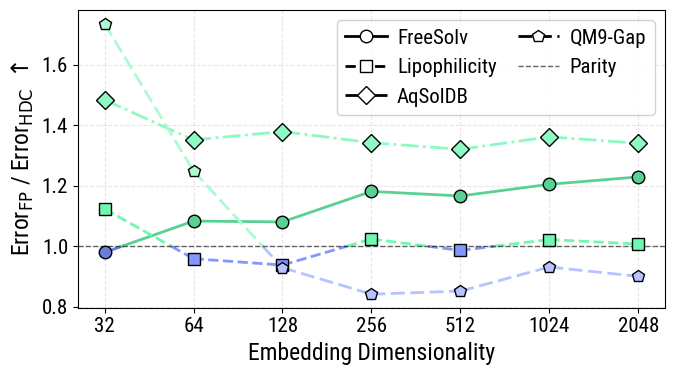

In [28]:
# ============================================================================
# DATASET SELECTION — toggle which datasets to include in the plot
# ============================================================================

INCLUDE_DATASETS: list[tuple[str, int, str]] = [
    ('freesolv',      0,  'FreeSolv'),
    ('lipophilicity', 0,  'Lipophilicity'),
    ('aqsoldb',       0,  'AqSolDB'),
    # ('qm9_smiles',   10,  'QM9-U₀'),
    ('qm9_smiles',    7,  'QM9-Gap'),
]

INCLUDE_SIZES: list[int] = [32, 64, 128, 256, 512, 1024, 2048]


# ============================================================================
# CONFIGURATION
# ============================================================================

FIGSIZE: tuple = (7, 4)
FONT_SIZE: int = 15
SHOW_ERROR_BARS: bool = False

COLOR_HDC: str = '#69F7AE'      # HDC color  — ratio > 1.0
COLOR_MORGAN: str = '#7C92FF'   # Morgan color — ratio < 1.0

# Brightness per dataset: 0.0 = pure base color, positive = blend toward white,
# negative = blend toward black.  Range roughly [-0.5, 0.5].
DATASET_BRIGHTNESS: dict[tuple, float] = {
    ('freesolv',      0): -0.15,
    ('lipophilicity', 0):  0.05,
    ('aqsoldb',       0):  0.25,
    ('qm9_smiles',   10):  0.45,
    ('qm9_smiles',    7):  0.45,
}

DATASET_MARKERS: dict[tuple, str] = {
    ('freesolv',      0):  'o',
    ('lipophilicity', 0):  's',
    ('aqsoldb',       0):  'D',
    ('qm9_smiles',   10):  '^',
    ('qm9_smiles',    7):  'p',
}

DATASET_LINESTYLES: dict[tuple, str] = {
    ('freesolv',      0):  '-',
    ('lipophilicity', 0):  '--',
    ('aqsoldb',       0):  '-.',
    ('qm9_smiles',   10):  ':',
    ('qm9_smiles',    7):  (0, (5, 2)),
}

DATASET_LABEL_MAP: dict[tuple, str] = {
    ('freesolv',      0):  'FreeSolv',
    ('lipophilicity', 0):  'Lipophilicity',
    ('aqsoldb',       0):  'AqSolDB',
    ('qm9_smiles',   10):  'QM9-U₀',
    ('qm9_smiles',    7):  'QM9-Gap',
}


# ============================================================================
# HELPER: adjust brightness of a hex color
# ============================================================================

def _adjust_brightness(hex_color: str, amount: float) -> str:
    """
    Adjust the brightness of a hex color.

    *amount* > 0 blends toward white, *amount* < 0 blends toward black.
    The value is clamped so the result stays in [0, 255] per channel.
    """
    r = int(hex_color[1:3], 16) / 255
    g = int(hex_color[3:5], 16) / 255
    b = int(hex_color[5:7], 16) / 255

    if amount >= 0:
        # blend toward white
        r = r + (1.0 - r) * amount
        g = g + (1.0 - g) * amount
        b = b + (1.0 - b) * amount
    else:
        # blend toward black
        factor = 1.0 + amount  # amount is negative, so factor < 1
        r *= factor
        g *= factor
        b *= factor

    r = max(0.0, min(1.0, r))
    g = max(0.0, min(1.0, g))
    b = max(0.0, min(1.0, b))
    return f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'


# ============================================================================
# HELPER: draw a line segment that changes color at parity crossings
# ============================================================================

def _interpolate_crossing(x0, y0, x1, y1, parity=1.0):
    """Find the x position where the line between (x0,y0) and (x1,y1) crosses parity."""
    lx0, lx1 = np.log2(x0), np.log2(x1)
    t = (parity - y0) / (y1 - y0)
    lx_cross = lx0 + t * (lx1 - lx0)
    return 2 ** lx_cross


def plot_colored_line(ax, x_arr, y_arr, linestyle, marker, markersize,
                      color_above, color_below, parity=1.0, linewidth=2):
    """
    Plot a line whose color switches between *color_above* and *color_below*
    whenever it crosses the *parity* value.  Scatter markers are drawn on top
    with the color matching the value at that point.
    """
    for i in range(len(x_arr) - 1):
        x0, x1 = x_arr[i], x_arr[i + 1]
        y0, y1 = y_arr[i], y_arr[i + 1]

        crosses = (y0 - parity) * (y1 - parity) < 0

        if not crosses:
            col = color_above if y0 >= parity else color_below
            ax.plot([x0, x1], [y0, y1], color=col, linestyle=linestyle,
                    linewidth=linewidth, zorder=2)
        else:
            x_cross = _interpolate_crossing(x0, y0, x1, y1, parity)
            col0 = color_above if y0 >= parity else color_below
            col1 = color_above if y1 >= parity else color_below
            ax.plot([x0, x_cross], [y0, parity], color=col0,
                    linestyle=linestyle, linewidth=linewidth, zorder=2)
            ax.plot([x_cross, x1], [parity, y1], color=col1,
                    linestyle=linestyle, linewidth=linewidth, zorder=2)

    for xi, yi in zip(x_arr, y_arr):
        col = color_above if yi >= parity else color_below
        ax.plot(xi, yi, marker=marker, color=col, markersize=markersize,
                markeredgecolor='black', markeredgewidth=1.0, zorder=3)


# ============================================================================
# PLOT SETUP
# ============================================================================

plt.style.use('default')
plt.rcParams['font.family'] = 'Roboto Condensed'
plt.rcParams['font.size'] = FONT_SIZE

fig, ax = plt.subplots(figsize=FIGSIZE)


# ============================================================================
# PLOT RATIO LINES
# ============================================================================

for (ds_name, ti, _) in INCLUDE_DATASETS:
    ds_key = (ds_name, ti)
    sizes_available = []
    means = []
    stds = []

    for sz in INCLUDE_SIZES:
        ratios = ratio_data[ds_key].get(sz, [])
        if ratios:
            sizes_available.append(sz)
            means.append(np.mean(ratios))
            stds.append(np.std(ratios))

    if not sizes_available:
        continue

    sizes_arr = np.array(sizes_available)
    means_arr = np.array(means)
    stds_arr = np.array(stds)

    marker = DATASET_MARKERS[ds_key]
    linestyle = DATASET_LINESTYLES[ds_key]
    brightness = DATASET_BRIGHTNESS[ds_key]
    col_hdc = _adjust_brightness(COLOR_HDC, brightness)
    col_morgan = _adjust_brightness(COLOR_MORGAN, brightness)

    plot_colored_line(
        ax, sizes_arr, means_arr,
        linestyle=linestyle,
        marker=marker,
        markersize=9,
        color_above=col_hdc,
        color_below=col_morgan,
    )

    if SHOW_ERROR_BARS:
        ax.errorbar(
            sizes_arr, means_arr, yerr=stds_arr,
            fmt='none', ecolor='black', capsize=3, linewidth=0.8,
            capthick=0.8, zorder=1,
        )


# ============================================================================
# PARITY LINE
# ============================================================================

ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.6)


# ============================================================================
# LEGEND
# ============================================================================

from matplotlib.lines import Line2D

legend_handles = []

# Dataset entries (black linestyle, black marker edge, white fill)
for (ds_name, ti, _) in INCLUDE_DATASETS:
    ds_key = (ds_name, ti)
    legend_handles.append(Line2D(
        [0], [0],
        color='black',
        marker=DATASET_MARKERS[ds_key],
        linestyle=DATASET_LINESTYLES[ds_key],
        linewidth=2,
        markersize=9,
        markeredgecolor='black',
        markeredgewidth=1.0,
        markerfacecolor='white',
        label=DATASET_LABEL_MAP[ds_key],
    ))

# Parity
legend_handles.append(Line2D(
    [0], [0], color='black', linestyle='--', linewidth=1.0, alpha=0.6, label='Parity',
))

ax.legend(
    handles=legend_handles, loc='best', fontsize=FONT_SIZE, framealpha=0.9,
    ncol=2, columnspacing=1.0, handletextpad=0.5,
)


# ============================================================================
# AXIS CONFIGURATION
# ============================================================================

ax.set_xscale('log', base=2)
ax.set_xticks(INCLUDE_SIZES)
ax.set_xticklabels([str(s) for s in INCLUDE_SIZES])
ax.tick_params(axis='both', labelsize=FONT_SIZE)
ax.set_xlabel('Embedding Dimensionality', fontsize=FONT_SIZE + 2)
ax.set_ylabel(r'Error$_{\mathrm{FP}}$ / Error$_{\mathrm{HDC}}$ $\uparrow$', fontsize=FONT_SIZE + 2)

ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()

fig_path = os.path.join(PATH, 'figures', 'ex_10_knn_mae_ratio.pdf')
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
plt.savefig(fig_path, bbox_inches='tight')
print(f'Saved to {fig_path}')

plt.show()
fig

## Per-Dataset MAE Comparison (Individual Box Plots)

Box plots showing the raw MAE distributions for Morgan FP and HDC side by side
at each embedding size, one subplot per dataset.

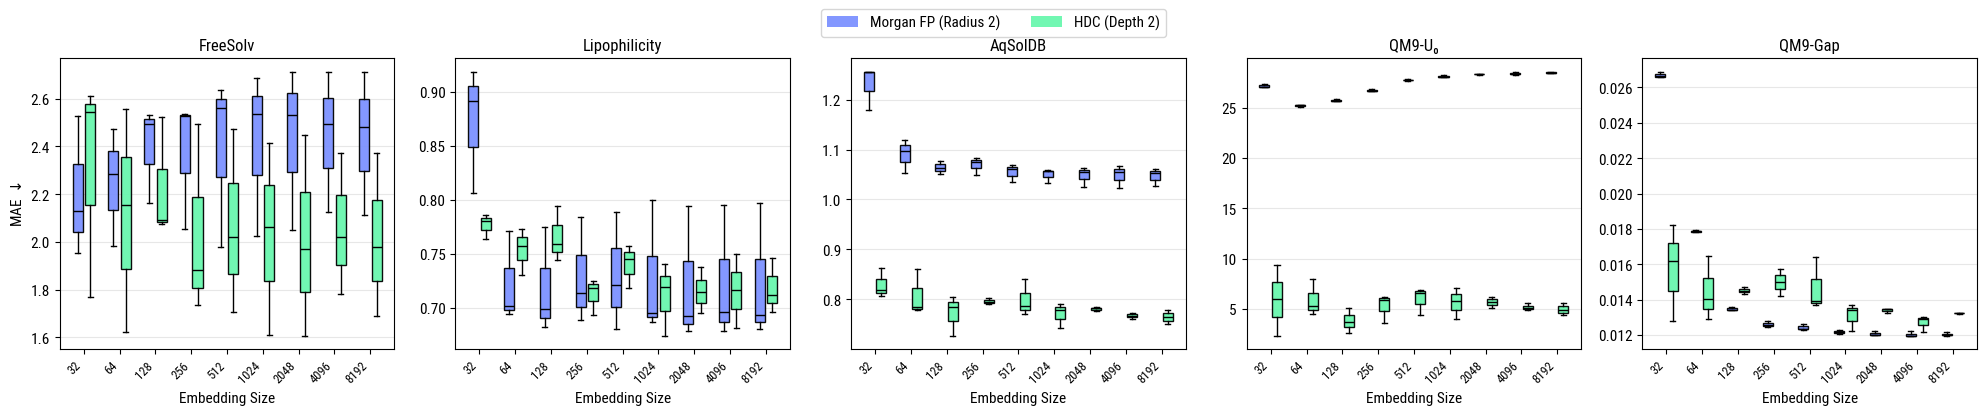

In [22]:
# ============================================================================
# CONFIGURATION
# ============================================================================

COLORS_ENC = {
    'fp':  '#7C92FF',
    'hdc': '#69F7AE',
}
LABELS_ENC = {
    'fp':  'Morgan FP (Radius 2)',
    'hdc': 'HDC (Depth 2)',
}


# ============================================================================
# PLOT
# ============================================================================

plt.style.use('default')
plt.rcParams['font.family'] = 'Roboto Condensed'
plt.rcParams['font.size'] = FONT_SIZE

n_datasets = len(DATASET_KEYS)
fig, axes = plt.subplots(1, n_datasets, figsize=(4 * n_datasets, 4), sharey=False)

for ax_idx, (ds_name, ti, ds_label) in enumerate(DATASET_KEYS):
    ax = axes[ax_idx]
    box_width = 0.35
    offsets = {'fp': -box_width / 2, 'hdc': box_width / 2}

    for enc in ['fp', 'hdc']:
        for size_idx, sz in enumerate(EMBEDDING_SIZES):
            vals = [mae_table.get((enc, ds_name, ti, sz, sd)) for sd in SEEDS]
            vals = [v for v in vals if v is not None]
            if not vals:
                continue

            pos = size_idx + offsets[enc]
            ax.boxplot(
                [vals], positions=[pos], widths=box_width * 0.8,
                patch_artist=True, showfliers=True,
                boxprops=dict(facecolor=COLORS_ENC[enc], alpha=0.95,
                              edgecolor='black', linewidth=1.0),
                medianprops=dict(color='black', linewidth=1.0),
                whiskerprops=dict(color='black', linewidth=1.0),
                capprops=dict(color='black', linewidth=1.0),
                flierprops=dict(marker='o', markerfacecolor='black',
                                markersize=4, alpha=0.3),
            )

    ax.set_xticks(range(len(EMBEDDING_SIZES)))
    ax.set_xticklabels(EMBEDDING_SIZES, rotation=45, ha='right', fontsize=FONT_SIZE - 2)
    ax.set_title(ds_label, fontsize=FONT_SIZE + 1)
    ax.set_xlabel('Embedding Size', fontsize=FONT_SIZE)
    if ax_idx == 0:
        ax.set_ylabel('MAE $\\downarrow$', fontsize=FONT_SIZE)
    ax.grid(True, alpha=0.3, axis='y')

# Shared legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS_ENC['fp'],  alpha=0.95, label=LABELS_ENC['fp']),
    Patch(facecolor=COLORS_ENC['hdc'], alpha=0.95, label=LABELS_ENC['hdc']),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2,
           fontsize=FONT_SIZE, bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.show()
fig

## Summary Statistics

In [11]:
print('Overall ratio statistics per dataset (across all sizes and seeds):')
print(f'{"Dataset":>15} | {"Mean Ratio":>10} | {"Min":>6} | {"Max":>6} | {"% > 1.0":>8}')
print('-' * 60)

for (ds_name, ti, ds_label) in DATASET_KEYS:
    all_ratios = []
    for sz in EMBEDDING_SIZES:
        all_ratios.extend(ratio_data[(ds_name, ti)].get(sz, []))

    if all_ratios:
        arr = np.array(all_ratios)
        pct_above = 100 * np.mean(arr > 1.0)
        print(f'{ds_label:>15} | {np.mean(arr):>10.3f} | {np.min(arr):>6.3f} | {np.max(arr):>6.3f} | {pct_above:>7.1f}%')
    else:
        print(f'{ds_label:>15} | {"N/A":>10} | {"N/A":>6} | {"N/A":>6} | {"N/A":>8}')

Overall ratio statistics per dataset (across all sizes and seeds):
        Dataset | Mean Ratio |    Min |    Max |  % > 1.0
------------------------------------------------------------
       FreeSolv |      1.149 |  0.767 |  1.378 |    85.2%
  Lipophilicity |      1.008 |  0.908 |  1.177 |    51.9%
        AqSolDB |      1.368 |  1.271 |  1.535 |   100.0%
         QM9-U₀ |      5.586 |  2.914 | 11.705 |   100.0%
        QM9-Gap |      1.038 |  0.769 |  2.084 |    23.1%
